# Comparison of Dependency Measures: F-test vs Correlation vs Covariance vs MI vs MI Invariant

This example compares five common measures of statistical dependency between variables:

- **F-test** (`sklearn.feature_selection.f_regression`): Captures only linear dependencies.
- **Pearson Correlation**: Measures linear relationship strength, normalized to [-1, 1].
- **Covariance**: Measures joint variability, but is scale-dependent.
- **Mutual Information** (`sklearn.feature_selection.mutual_info_regression`): Captures any dependency, but estimates can vary with scale.
- **MI Invariant** (`entropy_invariant.mutual_information`): Captures any dependency and is **invariant under scaling and translation**.

We generate a target variable $y$ that depends on three features:

$$y = x_1 + \sin(6\pi x_2) + 0.1 \cdot \varepsilon$$

- $x_1$: linear relationship with $y$
- $x_2$: non-linear (sinusoidal) relationship with $y$
- $x_3$: completely irrelevant (noise)

A good dependency measure should detect both $x_1$ and $x_2$ as informative, and $x_3$ as irrelevant.

Inspired by the [scikit-learn F-test vs MI example](https://scikit-learn.org/1.1/auto_examples/feature_selection/plot_f_test_vs_mi.html).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_selection import f_regression, mutual_info_regression
from entropy_invariant import mutual_information as mi_invariant

## Generate Synthetic Data

In [2]:
np.random.seed(0)
n = 1000

X = np.random.rand(n, 3)
y = X[:, 0] + np.sin(6 * np.pi * X[:, 1]) + 0.1 * np.random.randn(n)

feature_names = ["$x_1$ (linear)", "$x_2$ (non-linear)", "$x_3$ (irrelevant)"]

## Compute Dependency Measures

In [3]:
# F-test
f_test, _ = f_regression(X, y)
f_test /= np.max(f_test)

# Pearson correlation (absolute value)
correlation = np.array([np.abs(np.corrcoef(X[:, i], y)[0, 1]) for i in range(3)])
correlation /= np.max(correlation)

# Covariance (absolute value)
covariance = np.array([np.abs(np.cov(X[:, i], y)[0, 1]) for i in range(3)])
covariance /= np.max(covariance)

# Mutual information (sklearn)
mi_sklearn = mutual_info_regression(X, y, random_state=0)
mi_sklearn /= np.max(mi_sklearn)

# MI Invariant (entropy-invariant package)
mi_inv = np.array([mi_invariant(X[:, i], y) for i in range(3)])
mi_inv /= np.max(mi_inv)

print(f"{'Measure':<20} {'x1 (linear)':>12} {'x2 (non-lin)':>12} {'x3 (noise)':>12}")
print("-" * 58)
for name, values in [("F-test", f_test), ("Correlation", correlation),
                      ("Covariance", covariance), ("MI (sklearn)", mi_sklearn),
                      ("MI Invariant", mi_inv)]:
    print(f"{name:<20} {values[0]:>12.3f} {values[1]:>12.3f} {values[2]:>12.3f}")

Measure               x1 (linear) x2 (non-lin)   x3 (noise)
----------------------------------------------------------
F-test                      1.000        0.280        0.003
Correlation                 1.000        0.562        0.055
Covariance                  1.000        0.549        0.053
MI (sklearn)                0.364        1.000        0.000
MI Invariant                0.370        1.000        0.004


## Visualization: Scatter Plots with All Measures

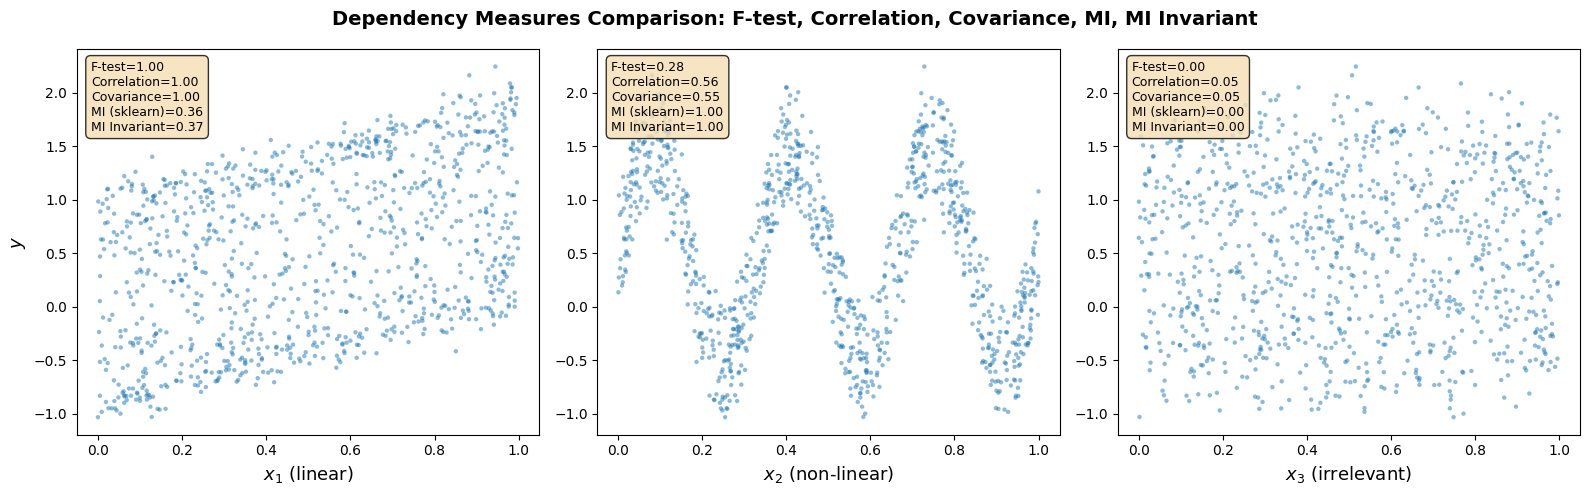

In [4]:
measures = {
    "F-test": f_test,
    "Correlation": correlation,
    "Covariance": covariance,
    "MI (sklearn)": mi_sklearn,
    "MI Invariant": mi_inv,
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i in range(3):
    axes[i].scatter(X[:, i], y, s=10, alpha=0.5, edgecolor="none")
    axes[i].set_xlabel(feature_names[i], fontsize=13)
    if i == 0:
        axes[i].set_ylabel("$y$", fontsize=13)

    # Build annotation text
    text = "\n".join(f"{name}={values[i]:.2f}" for name, values in measures.items())
    axes[i].annotate(
        text,
        xy=(0.03, 0.97), xycoords="axes fraction",
        verticalalignment="top", fontsize=9,
        bbox=dict(boxstyle="round,pad=0.4", facecolor="wheat", alpha=0.8),
    )

fig.suptitle(
    "Dependency Measures Comparison: F-test, Correlation, Covariance, MI, MI Invariant",
    fontsize=14, fontweight="bold",
)
plt.tight_layout()
plt.show()

## Bar Chart Comparison

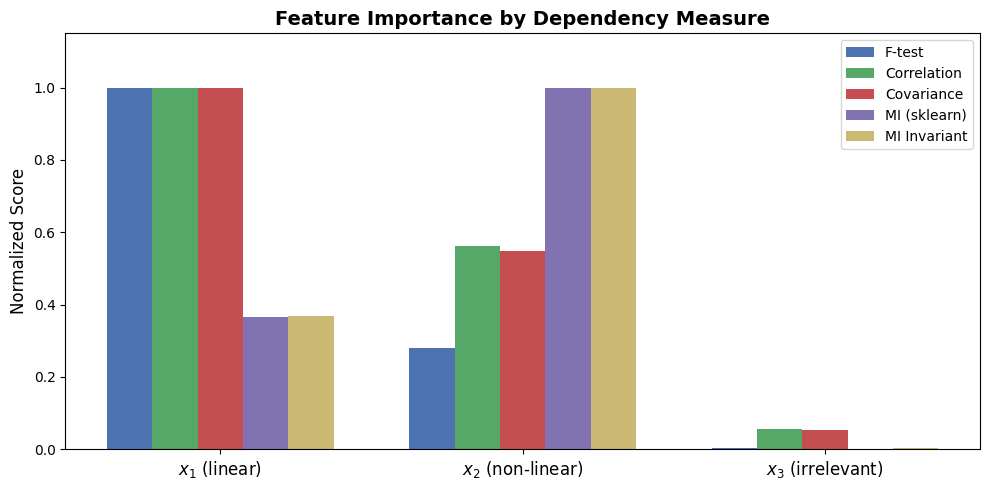

In [5]:
x_pos = np.arange(3)
width = 0.15
colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2", "#CCB974"]

fig, ax = plt.subplots(figsize=(10, 5))

for j, (name, values) in enumerate(measures.items()):
    ax.bar(x_pos + j * width, values, width, label=name, color=colors[j])

ax.set_xticks(x_pos + 2 * width)
ax.set_xticklabels(["$x_1$ (linear)", "$x_2$ (non-linear)", "$x_3$ (irrelevant)"], fontsize=12)
ax.set_ylabel("Normalized Score", fontsize=12)
ax.set_title("Feature Importance by Dependency Measure", fontsize=14, fontweight="bold")
ax.legend(loc="upper right")
ax.set_ylim(0, 1.15)
plt.tight_layout()
plt.show()

## Scale Invariance: The Core Innovation

### Why is MI already scale-invariant?

The real mechanism is the **normalization step**, not the estimator that runs after it. Every
entropy-invariant function first divides each variable by its own invariant measure `r_X` (median
nearest-neighbor distance times `n`). That measure is exactly linear in scale: `r_{aX} = |a| * r_X`,
so

$$\frac{aX}{r_{aX}} = \frac{aX}{|a|\, r_X} = \text{sign}(a)\,\frac{X}{r_X}$$

the normalized variable is unchanged (up to sign) regardless of `a`. Everything downstream --
whether that is `method="inv"`'s entropy differencing or the default `method="inv_ksg"`'s
shared-radius KSG/Frenzel-Pompe counting -- operates on this already-invariant quantity, so both are
scale-invariant by construction, independent of which k-NN algorithm runs after normalizing.

(For readers used to the plug-in view: with `method="inv"`, the k-NN entropy estimator shifts by
$\log|a|$ under scaling, $H(aX) = H(X) + \log|a|$, and these shifts cancel in the MI difference
$I(aX;bY) = H(aX)+H(bY)-H(aX,bY)$ -- but that cancellation is a *consequence* of the normalization
already having removed the scale dependence, not an independent source of invariance.)

F-test and correlation are also scale-invariant, for an unrelated reason: they are ratios (of sums of
squares / of covariance to standard deviations) that cancel scale factors directly.

### Where sklearn MI breaks: asymmetric scaling

**sklearn does not normalize at all.** Reading `sklearn.feature_selection._mutual_info._compute_mi_cc`
confirms it runs the raw KSG estimator directly on the untouched `x`, `y` values, using a **Chebyshev
(max-norm) joint distance**: `radius = max(|dx|, |dy|)`. There is no `/std` step for MI (only
`mutual_info_classif` with `discrete_features` touches scaling elsewhere) -- so this isn't a
normalization difference, it's a **degeneracy of the raw joint metric**.

When $x$ is scaled down to $10^{-15}$ while $y$ stays at $O(1)$, the max-norm radius around every point
is set almost entirely by $y$ (since $|dx| \ll |dy|$ always). That radius, projected back onto the
$x$-marginal via `KDTree(x).query_radius`, is now enormous relative to $x$'s own (tiny) spread, so
*every* point counts as an $x$-neighbor -- $n_x \to n-1$ for essentially all points, and the digamma
terms that are supposed to measure $x$'s contribution saturate, driving the MI estimate toward zero.
The break point (~$10^{-15}$) lines up with float64 machine epsilon ($\approx 2.22\times10^{-16}$):
it's exactly where $x$'s differences stop being distinguishable from the noise floor relative to $y$'s
scale in the joint distance computation, not an artifact of any preprocessing step.

The **invariant method** normalizes each variable independently *before* the joint search, so neither
variable's marginal spread can be swamped by the other's -- it is robust to any scale mismatch by
construction, for a different reason than "it uses a better normalization than sklearn": sklearn
uses no normalization here at all.

### Entropy invariance

Standard differential entropy depends on units: $H(\text{meters}) \neq H(\text{centimeters})$.
The invariant estimator gives the same value regardless of scale — this matters whenever entropy
is used directly (maximum entropy modeling, information-theoretic feature selection, comparing
distributions with different units).

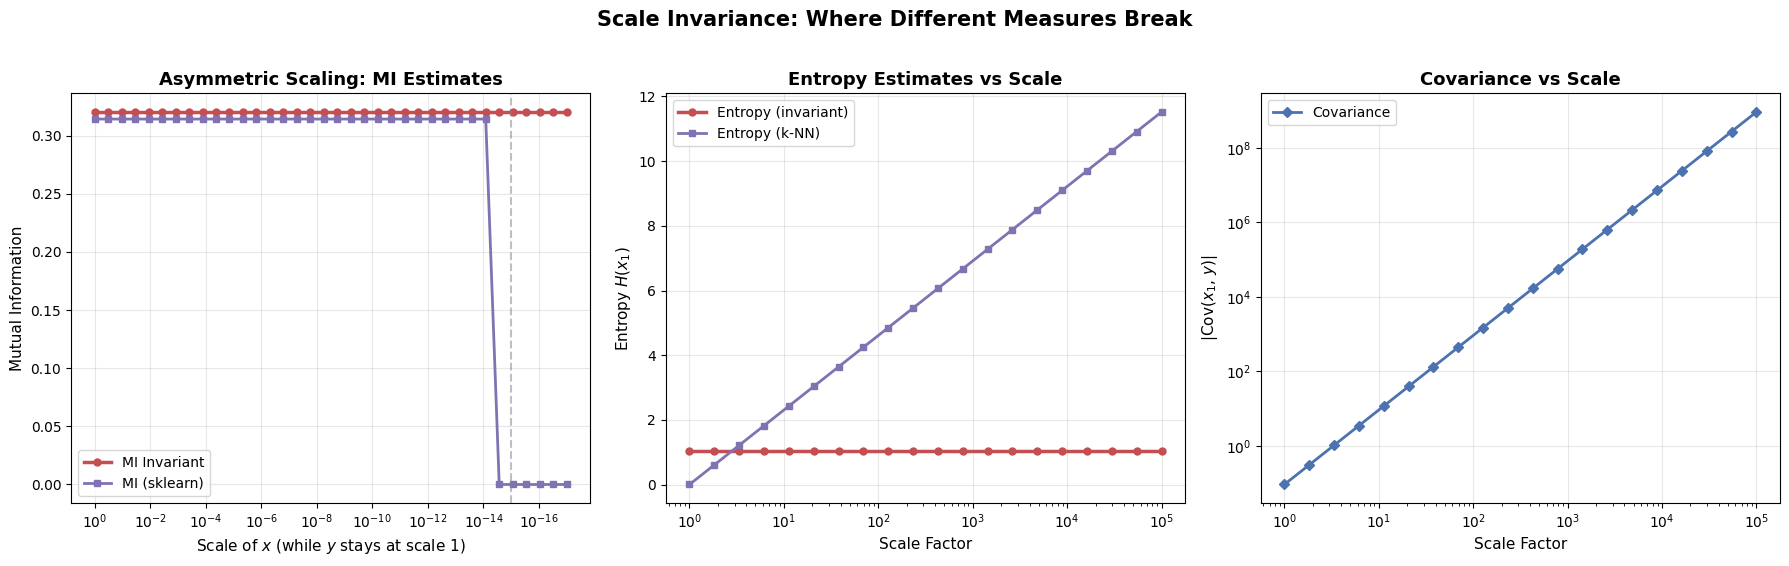

In [6]:
from entropy_invariant import entropy

x1 = X[:, 0]

# --- Plot 1: Asymmetric scaling - shrink X while keeping Y at scale 1 ---
x_scales = np.logspace(0, -17, 36)  # from 1 down to 1e-17

mi_inv_asym = []
mi_sk_asym = []

for sx in x_scales:
    xs = sx * x1
    mi_inv_asym.append(mi_invariant(xs, y))
    mi_sk_asym.append(mutual_info_regression(xs.reshape(-1, 1), y, random_state=0)[0])

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# Panel 1: Asymmetric MI comparison
ax = axes[0]
ax.semilogx(x_scales, mi_inv_asym, "o-", label="MI Invariant", color="#C44E52", linewidth=2.5, markersize=5)
ax.semilogx(x_scales, mi_sk_asym, "s-", label="MI (sklearn)", color="#8172B2", linewidth=2, markersize=5)
ax.set_xlabel("Scale of $x$ (while $y$ stays at scale 1)", fontsize=11)
ax.set_ylabel("Mutual Information", fontsize=11)
ax.set_title("Asymmetric Scaling: MI Estimates", fontsize=13, fontweight="bold")
ax.invert_xaxis()
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.axvline(x=1e-15, color="gray", linestyle="--", alpha=0.5)
ax.annotate("sklearn breaks\n(float64 limit)", xy=(1e-15, 0.9), fontsize=9, ha="center", color="gray")

# --- Plot 2: Entropy invariance across uniform scaling ---
scale_factors = np.logspace(0, 5, 20)
h_inv_vals = [entropy(s * x1, method="inv") for s in scale_factors]
h_knn_vals = [entropy(s * x1, method="knn") for s in scale_factors]

ax2 = axes[1]
ax2.semilogx(scale_factors, h_inv_vals, "o-", label="Entropy (invariant)", color="#C44E52", linewidth=2.5, markersize=5)
ax2.semilogx(scale_factors, h_knn_vals, "s-", label="Entropy (k-NN)", color="#8172B2", linewidth=2, markersize=5)
ax2.set_xlabel("Scale Factor", fontsize=11)
ax2.set_ylabel("Entropy $H(x_1)$", fontsize=11)
ax2.set_title("Entropy Estimates vs Scale", fontsize=13, fontweight="bold")
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

# --- Plot 3: Covariance exploding ---
cov_vals = [np.abs(np.cov(s * x1, s * y)[0, 1]) for s in scale_factors]

ax3 = axes[2]
ax3.loglog(scale_factors, cov_vals, "D-", label="Covariance", color="#4C72B0", linewidth=2, markersize=5)
ax3.set_xlabel("Scale Factor", fontsize=11)
ax3.set_ylabel("|Cov($x_1$, $y$)|", fontsize=11)
ax3.set_title("Covariance vs Scale", fontsize=13, fontweight="bold")
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)

fig.suptitle(
    "Scale Invariance: Where Different Measures Break",
    fontsize=15, fontweight="bold", y=1.02,
)
plt.tight_layout()
plt.show()

## Summary

### Dependency Detection

| Measure | Detects Linear | Detects Non-linear |
|---------|:-:|:-:|
| F-test | Yes | Poorly |
| Pearson Correlation | Yes | Poorly |
| Covariance | Yes | Poorly |
| MI (sklearn) | Yes | Yes |
| **MI Invariant** | **Yes** | **Yes** |

### Scale Behavior

| Measure / Estimator | Uniform scaling | Asymmetric scaling | Notes |
|---------------------|:-:|:-:|---|
| **MI Invariant** | Invariant | **Invariant** | Normalizes each variable independently |
| MI (sklearn) | Invariant | Breaks at ~$10^{15}$ ratio | k-NN joint distances dominated by large-scale axis |
| Correlation | Invariant | Invariant | But blind to non-linear dependencies |
| F-test | Invariant | Invariant | But blind to non-linear dependencies |
| Covariance | Grows as $a^2$ | Grows as $a^2$ | Not invariant at all |
| **Entropy (invariant)** | **Constant** | — | Core innovation of the package |
| Entropy (k-NN) | Drifts as $\log|a|$ | — | Standard differential entropy |

### Key Takeaways

1. **MI is scale-invariant because the normalization happens before any k-NN search** -- dividing by the invariant measure `r_X` removes the scale dependence up front, regardless of which algorithm (plug-in differencing or the default `inv_ksg` shared-radius KSG/Frenzel-Pompe) runs afterward (see "Scale Invariance: The Core Innovation" above)
2. **In practice**, sklearn's MI breaks under extreme scale mismatch between variables (float64 precision limit in joint k-NN distances)
3. **Entropy invariance** is the core innovation — $H(\text{meters}) = H(\text{centimeters})$ — useful whenever entropy is used directly
4. **MI Invariant** is the only measure that is both non-linear-aware and robust to any scale mismatch